# Detecting Robot Failures by Learning How a Robot Normally Moves

**Option 1 thesis project — RoboAI UR5e dataset**

## The main question

> **Can a model that has only seen a robot working normally tell us when something goes wrong?**

Robots are almost always recorded while working normally, so we have no examples of real failures to learn from. The idea: teach a model what *normal* motion looks like. When the robot moves in a way the model did not expect, raise an alarm.

## The three research questions (from the proposal)

| | Question | Answered in |
|---|---|---|
| **RQ1** | How accurately can a model trained only on normal demonstrations **predict** the robot's future motion? | Step 5 |
| **RQ2** | Can the model's surprise **detect failures** (collision, freeze, drift, sensor noise), how early, and which method works best? | Steps 8–9 |
| **RQ3** | Does giving the model the **robot's commands** reduce false alarms, because it can tell "the robot was told to stop" from "the robot got stuck"? | Step 10 |

Step 12 collects the final answers.

## The seven methods we compare

| Family | Method | How it decides "this is unusual" |
|---|---|---|
| Simple rules | **Rule: stays still** | Any movement at all is surprising |
| Simple rules | **Rule: keeps its speed** | Any change of speed is surprising |
| Classic machine learning | **Isolation Forest** | This piece of motion looks unlike the normal pieces it has seen |
| Neural network (rebuild) | **LSTM autoencoder** | It cannot rebuild this piece of motion well |
| Neural network (predict) | **GRU forecaster** | The robot did not move the way it predicted |
| Neural network (predict) | **Transformer forecaster** | Same as the GRU, with a different, attention-based network |
| **New idea** | **Command-aware GRU** | Same as the GRU, but it also knows which commands the robot received |

The GRU and the command-aware GRU are **identical except for the commands**, so any difference between them is caused by the commands alone. That makes RQ3 a fair test.

> **Spoiler for RQ3:** the data check in Step 2 shows that this dataset's "commands" are just the recorded movement written down a second time. Step 10 explains why this means RQ3 cannot be answered with this dataset, and what to do instead.

## How to read this notebook

Every step has the same three parts:
- **What we do** — the plan in plain words
- **What we get** — what the step produces
- **➜ Result** — printed by the code, with the numbers from this run

Everything runs on a normal laptop in a few minutes; a GPU is used automatically if there is one.

## Step 0 — Setup

**What we do:** load the Python libraries and set the main settings.

- `K = 10`: the model looks at the last 10 time steps
- `H = 10`: forecasters predict the next 10 time steps

In [1]:
# %pip install numpy pandas matplotlib torch scikit-learn   (tensorflow + tensorflow-datasets only for Step 1)
import os, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.ensemble import IsolationForest

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_PATH = r"C:\Users\Nahid\Test\dataset"                     # only needed once, for Step 1
PROCESSED_PATH = r"C:\Users\Nahid\Test\processed\robot_motion.npz"
RESULTS_DIR = r"C:\Users\Nahid\Test\results"
os.makedirs(RESULTS_DIR, exist_ok=True)

SEED = 0
K = 10   # past steps each method looks at
H = 10   # future steps the forecasters predict

def seed_all(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_all()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)
print(f"➜ Result: running on {DEVICE}  (PyTorch {torch.__version__})")

➜ Result: running on cuda  (PyTorch 2.5.1+cu121)


## Step 1 — Get the data

**What we do:** read only the numbers we need from the 24 GB dataset — the robot state (15 values), the commands (7 values) and the task sentence — and save them into one small file. Camera images are skipped.

**What we get:** `processed/robot_motion.npz` (~4 MB). If the file already exists, this step is skipped, so the rest of the notebook works without the big dataset (e.g. on a laptop or in Google Colab).

In [2]:
if os.path.exists(PROCESSED_PATH):
    print("File already exists, skipping extraction:", PROCESSED_PATH)
else:
    import tensorflow as tf
    tf.config.set_visible_devices([], "GPU")
    import tensorflow_datasets as tfds

    builder = tfds.builder_from_directory(DATASET_PATH)
    split_info = builder.info.splits["train"]
    available = 0   # also works with a partial download (first contiguous shards)
    for i, n in enumerate(split_info.shard_lengths):
        shard = f"{builder.info.name}-train.tfrecord-{i:05d}-of-{split_info.num_shards:05d}"
        if not os.path.exists(os.path.join(DATASET_PATH, shard)):
            break
        available += n
    split = "train" if available == split_info.num_examples else f"train[:{available}]"

    decoders = {"steps": {"observation": {"image": tfds.decode.SkipDecoding()}}}
    states, actions, lengths, instructions, file_names = [], [], [], [], []
    t0 = time.time()
    for ep in builder.as_dataset(split=split, decoders=decoders):
        steps = ep["steps"].map(lambda s: (s["observation"]["robot_state"], s["action"], s["language_instruction"]))
        s_ep, a_ep, instr = [], [], b""
        for s, a, text in steps:
            s_ep.append(s.numpy()); a_ep.append(a.numpy()); instr = text.numpy()
        states.append(np.stack(s_ep)); actions.append(np.stack(a_ep)); lengths.append(len(s_ep))
        instructions.append(instr.decode("utf-8"))
        file_names.append(ep["episode_metadata"]["file_name"].numpy().decode("utf-8"))

    os.makedirs(os.path.dirname(PROCESSED_PATH), exist_ok=True)
    np.savez_compressed(PROCESSED_PATH, states=np.concatenate(states).astype(np.float32),
                        actions=np.concatenate(actions).astype(np.float32), lengths=np.array(lengths),
                        instructions=np.array(instructions), file_names=np.array(file_names))
    print(f"Extracted {len(lengths)} recordings in {time.time() - t0:.0f}s")

print(f"➜ Result: data file ready, {os.path.getsize(PROCESSED_PATH) / 1e6:.1f} MB")

File already exists, skipping extraction: C:\Users\Nahid\Test\processed\robot_motion.npz
➜ Result: data file ready, 4.0 MB


## Step 2 — Clean the data and split it

**What we do:**

1. **Name the values.** Robot state (inferred from the numbers — confirm with the dataset author):

   | index | name | meaning |
   |---|---|---|
   | 0–5 | `joint0`…`joint5` | the 6 joint angles [rad] |
   | 6–8 | `x`, `y`, `z` | hand position [m] |
   | 9–12 | `q0`…`q3` | hand orientation (quaternion) |
   | 13 | `gripper` | 0 = open, 1 = closed |
   | 14 | — | always 0, removed |

   Commands used: hand movement `dx dy dz` and the gripper command. A **data check** below shows that these recorded commands are *exactly* the change of the hand position since the previous step, and the current gripper state. So we rebuild them from the positions; that way, damaged test recordings (Step 6) get matching commands, just as a real failure would change both. The recorded rotation commands are left out, because their link to the orientation could not be reconstructed.

2. **Fix sign flips.** A quaternion *q* and *−q* mean the same orientation, but the recording sometimes switches between them. To a model this looks like a sudden jump — a fake failure. We flip it back.

3. **Split by recording:** 70 % to train, 15 % to tune (validation), 15 % to test. A method never sees any part of a test recording while learning.

4. **Scale** every value to a similar range (using the training recordings only).

**What we get:** clean, scaled recordings and a fixed train/validation/test split.

In [3]:
data = np.load(PROCESSED_PATH)
lengths = data["lengths"]
offsets = np.concatenate([[0], np.cumsum(lengths)])
instructions, file_names = data["instructions"], data["file_names"]
raw_states = [data["states"][offsets[i]:offsets[i + 1]] for i in range(len(lengths))]
raw_cmds = [data["actions"][offsets[i]:offsets[i + 1]] for i in range(len(lengths))]

ALL_NAMES = [f"joint{i}" for i in range(6)] + ["x", "y", "z", "q0", "q1", "q2", "q3", "gripper", "unused"]
CMD_NAMES = ["dx", "dy", "dz", "gripper_cmd"]

def fix_quaternion_signs(s, q=slice(9, 13)):
    s = s.copy()
    for t in range(1, len(s)):
        if np.dot(s[t, q], s[t - 1, q]) < 0:
            s[t, q] *= -1
    return s

flips = sum(int((np.einsum("ij,ij->i", s[1:, 9:13], s[:-1, 9:13]) < 0).sum()) for s in raw_states)
states = [fix_quaternion_signs(s) for s in raw_states]

keep = np.concatenate(states).std(0) > 1e-6
NAMES = [n for n, k in zip(ALL_NAMES, keep) if k]
states = [s[:, keep] for s in states]
D, A = len(NAMES), len(CMD_NAMES)
GRIPPER = NAMES.index("gripper")
XYZ = [NAMES.index(n) for n in ("x", "y", "z")]
CONT_DIMS = [i for i in range(D) if i != GRIPPER]   # scores ignore the gripper (open/close timing is hard to predict)

def commands_from_states(s):
    """Hand movement since the previous step + current gripper state (how the dataset's commands are defined)."""
    move = np.vstack([np.zeros((1, 3), s.dtype), np.diff(s[:, XYZ], axis=0)])
    return np.concatenate([move, s[:, [GRIPPER]]], axis=1)

cmds = [commands_from_states(s) for s in states]

# Data check: do the rebuilt commands equal the recorded ones?
rec = np.concatenate([c[:, [0, 1, 2, 6]] for c in raw_cmds])
CMD_EQUALS_PAST_MOVE = float(np.mean(np.all(np.abs(np.concatenate(cmds) - rec) < 1e-6, axis=1)))

rng = np.random.default_rng(SEED)
order = rng.permutation(len(states))
n_val = n_test = int(0.15 * len(order))
VAL, TEST, TRAIN = order[:n_val], order[n_val:n_val + n_test], order[n_val + n_test:]

MU, SD = np.concatenate([states[i] for i in TRAIN]).mean(0), np.concatenate([states[i] for i in TRAIN]).std(0)
CMU = np.concatenate([cmds[i] for i in TRAIN]).mean(0)
CSD = np.concatenate([cmds[i] for i in TRAIN]).std(0)
CSD = np.where(CSD < 1e-6, 1.0, CSD)
Z = [((s - MU) / SD).astype(np.float32) for s in states]          # scaled states
C = [((c - CMU) / CSD).astype(np.float32) for c in cmds]           # scaled commands
STEP_SD = np.concatenate([np.diff(Z[i], axis=0) for i in TRAIN]).std(0)

def commands_from_scaled(z):
    """Commands for a (possibly damaged) scaled recording, rebuilt the same way as the dataset defines them."""
    return ((commands_from_states(z * SD + MU) - CMU) / CSD).astype(np.float32)

print(f"➜ Result: {len(states)} recordings, {offsets[-1]} time steps, {D} state values, {A} command values")
print(f"          fixed {flips} quaternion sign flips")
print(f"          split: {len(TRAIN)} train / {len(VAL)} validation / {len(TEST)} test recordings")
print(f"          data check: recorded command == (hand movement since last step, gripper state) "
      f"for {CMD_EQUALS_PAST_MOVE:.1%} of steps")

➜ Result: 443 recordings, 57742 time steps, 14 state values, 4 command values
          fixed 359 quaternion sign flips
          split: 311 train / 66 validation / 66 test recordings
          data check: recorded command == (hand movement since last step, gripper state) for 100.0% of steps


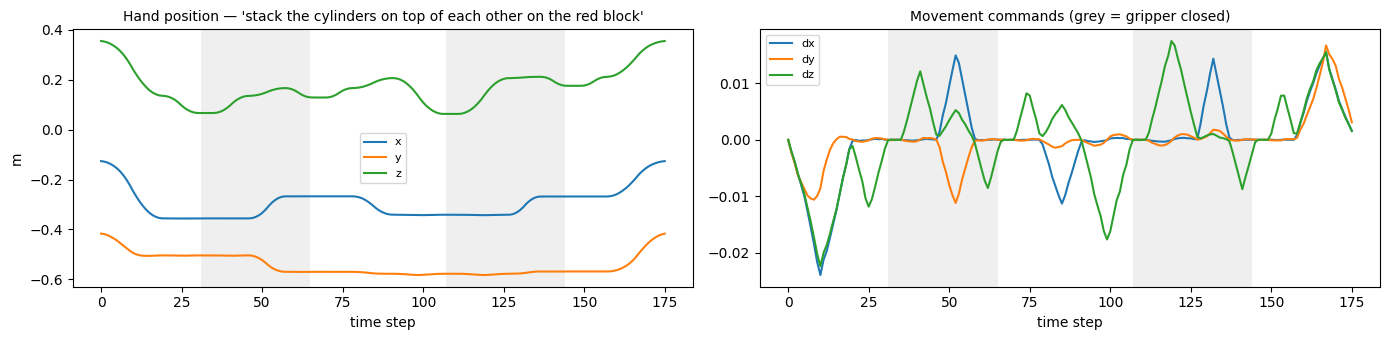

In [4]:
# A look at one training recording: hand position, gripper and the commands that drove them
i = TRAIN[0]
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for d in XYZ:
    axes[0].plot(states[i][:, d], label=NAMES[d])
g = states[i][:, GRIPPER]
for ax in axes:
    ax.fill_between(range(len(g)), 0, 1, where=g > 0.5, transform=ax.get_xaxis_transform(), color="grey", alpha=0.12, lw=0)
axes[0].set_title(f"Hand position — '{instructions[i]}'", fontsize=10); axes[0].set_ylabel("m"); axes[0].legend(fontsize=8)
for j in range(3):
    axes[1].plot(cmds[i][:, j], label=CMD_NAMES[j])
axes[1].set_title("Movement commands (grey = gripper closed)", fontsize=10); axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("time step")
plt.tight_layout(); plt.show()

## Step 3 — Cut the recordings into short training examples

**What we do:** slide a window along every recording. Each example contains:

```
 past states      z[t-10] … z[t-1]            (what every method sees)
 past commands    c[t-10] … c[t-1]            (only the command-aware GRU uses these)
 future states    z[t] … z[t+9]               (what the forecasters must predict)
```

Only commands that are already known at time *t−1* are used. In this dataset, the command at step *t* is computed from the state at step *t* (see the data check in Step 2), so any later command would reveal the future and make the comparison unfair.

**What we get:** tens of thousands of short examples for training, validation and testing.

In [5]:
def make_windows(idx):
    """Past states X (N,K,D), past commands Cw (N,K,A), future changes Y (N,H,D)."""
    X, Cw, Y = [], [], []
    for i in idx:
        z, c = Z[i], C[i]
        if len(z) < K + H:
            continue
        wz = sliding_window_view(z, K + H, axis=0).transpose(0, 2, 1)
        wc = sliding_window_view(c, K, axis=0).transpose(0, 2, 1)[:len(wz)]
        X.append(wz[:, :K]); Y.append(wz[:, K:] - wz[:, K - 1:K]); Cw.append(wc)
    return (np.concatenate(X).astype(np.float32), np.concatenate(Cw).astype(np.float32),
            np.concatenate(Y).astype(np.float32))

Xtr, Ctr, Ytr = make_windows(TRAIN)
Xva, Cva, Yva = make_windows(VAL)
Xte, Cte, Yte = make_windows(TEST)
Y_SD = Ytr.reshape(len(Ytr), -1).std(0).reshape(H, D) + 1e-6
Y_SD_T = torch.tensor(Y_SD, device=DEVICE)
print(f"➜ Result: {len(Xtr)} training / {len(Xva)} validation / {len(Xte)} test examples")

➜ Result: 34227 training / 7906 validation / 7192 test examples


## Step 4 — Build and train the seven methods

**What we do:** set up the two simple rules, then train the five learning methods on the **training recordings only**. Neural networks stop training when they stop improving on the validation recordings (early stopping).

**What we get:** seven trained methods and their training times.

### 4a — Simple rules (no training)

In [6]:
def rule_stays_still(X, Cw):
    return np.zeros((len(X), H, D), np.float32)

def rule_keeps_speed(X, Cw):
    v = X[:, -1] - X[:, -2]
    return (np.arange(1, H + 1)[None, :, None] * v[:, None, :]).astype(np.float32)

print("➜ Result: 2 rules ready (no training needed)")

➜ Result: 2 rules ready (no training needed)


### 4b — Shared training code for the neural networks

In [7]:
def with_velocity(x):
    """Adds the step-to-step change as extra input features."""
    return torch.cat([x, torch.diff(x, dim=1, prepend=x[:, :1])], dim=-1)

def train_torch(model, loss_fn, train, val, epochs=80, batch=512, lr=2e-3, patience=10):
    """Trains with AdamW + early stopping on the validation loss. Returns (model, history, seconds)."""
    t0 = time.time()
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    train = [torch.as_tensor(t, device=DEVICE) for t in train]
    val = [torch.as_tensor(t, device=DEVICE) for t in val]
    best, best_state, wait, history = np.inf, None, 0, []
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(train[0]), device=DEVICE)
        losses = []
        for i in range(0, len(perm), batch):
            b = perm[i:i + batch]
            loss = loss_fn(model, *[t[b] for t in train])
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            v = float(np.mean([loss_fn(model, *[t[i:i + 4096] for t in val]).item()
                               for i in range(0, len(val[0]), 4096)]))
        history.append((float(np.mean(losses)), v))
        if v < best - 1e-5:
            best, best_state, wait = v, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    return model, history, time.time() - t0

forecast_loss = lambda m, x, c, y: F.mse_loss(m(x, c), y / Y_SD_T)

def as_forecaster(model):
    """Wraps a trained network as predict(X, Cw) -> future changes (N,H,D)."""
    def predict(X, Cw):
        out = []
        with torch.no_grad():
            for i in range(0, len(X), 4096):
                x = torch.as_tensor(np.ascontiguousarray(X[i:i + 4096]), device=DEVICE)
                c = torch.as_tensor(np.ascontiguousarray(Cw[i:i + 4096]), device=DEVICE)
                out.append((model(x, c) * Y_SD_T).cpu().numpy())
        return np.concatenate(out) if out else np.zeros((0, H, D), np.float32)
    return predict

TRAIN_TIME, HISTORY = {}, {}

### 4c — GRU forecaster and Command-aware GRU (the new idea)

Both use the **same network**: an *encoder* reads the past 10 time steps, a *decoder* rolls forward 10 steps into the future.

- **GRU forecaster:** the encoder sees the past states only (its command input is all zeros).
- **Command-aware GRU:** the encoder also sees the past 10 commands.

In [8]:
class Seq2SeqGRU(nn.Module):
    def __init__(self, use_commands, hidden=128):
        super().__init__()
        self.use_commands = use_commands
        self.encoder = nn.GRU(2 * D + A, hidden, num_layers=2, batch_first=True, dropout=0.1)
        self.decoder = nn.GRU(1, hidden, num_layers=2, batch_first=True, dropout=0.1)
        self.head = nn.Linear(hidden, D)

    def forward(self, x, c):
        if not self.use_commands:
            c = torch.zeros_like(c)
        _, h = self.encoder(torch.cat([with_velocity(x), c], dim=-1))
        steps = torch.zeros(len(x), H, 1, device=x.device)    # the decoder only rolls the memory forward
        out, _ = self.decoder(steps, h)
        return self.head(out)                                  # (N, H, D)

for name, use_cmd in [("GRU forecaster", False), ("Command-aware GRU", True)]:
    seed_all()
    net, HISTORY[name], TRAIN_TIME[name] = train_torch(Seq2SeqGRU(use_cmd), forecast_loss,
                                                       (Xtr, Ctr, Ytr), (Xva, Cva, Yva))
    globals()["gru_net" if not use_cmd else "cmd_gru_net"] = net
    print(f"➜ Result: {name} trained in {TRAIN_TIME[name]:.0f}s ({len(HISTORY[name])} epochs)")

➜ Result: GRU forecaster trained in 7s (27 epochs)


➜ Result: Command-aware GRU trained in 5s (25 epochs)


### 4d — Transformer forecaster

The same job as the GRU forecaster, with an attention-based network (the architecture behind ChatGPT): it learns which of the last 10 moments matter most for the prediction. It does not use commands.

In [9]:
class TransformerForecaster(nn.Module):
    def __init__(self, d_model=64, heads=4, layers=2):
        super().__init__()
        self.inp = nn.Linear(2 * D, d_model)
        self.pos = nn.Parameter(torch.zeros(1, K, d_model))
        layer = nn.TransformerEncoderLayer(d_model, heads, dim_feedforward=128, dropout=0.1, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, layers, enable_nested_tensor=False)
        self.head = nn.Linear(d_model, H * D)

    def forward(self, x, c):
        h = self.encoder(self.inp(with_velocity(x)) + self.pos)
        return self.head(h[:, -1]).view(-1, H, D)

seed_all()
transformer_net, HISTORY["Transformer forecaster"], TRAIN_TIME["Transformer forecaster"] = train_torch(
    TransformerForecaster(), forecast_loss, (Xtr, Ctr, Ytr), (Xva, Cva, Yva), lr=1e-3)
print(f"➜ Result: Transformer trained in {TRAIN_TIME['Transformer forecaster']:.0f}s "
      f"({len(HISTORY['Transformer forecaster'])} epochs)")

FORECASTERS = {
    "Rule: stays still": rule_stays_still,
    "Rule: keeps its speed": rule_keeps_speed,
    "GRU forecaster": as_forecaster(gru_net),
    "Transformer forecaster": as_forecaster(transformer_net),
    "Command-aware GRU": as_forecaster(cmd_gru_net),
}

➜ Result: Transformer trained in 12s (53 epochs)


### 4e — LSTM autoencoder (a different neural approach)

It does not predict the future. It squeezes each 10-step piece of motion through a small "bottleneck" and tries to rebuild it. It learns to rebuild *normal* motion well, so motion it cannot rebuild is unusual.

In [10]:
def center(x):
    """Removes each window's average position, so the methods look at the *shape* of the motion."""
    return x - x.mean(axis=1, keepdims=True)

AE_SCALE = np.maximum(center(Xtr).reshape(-1, D).std(0), 1e-3).astype(np.float32)
ae_input = lambda X: (center(X) / AE_SCALE).astype(np.float32)

class LSTMAutoencoder(nn.Module):
    def __init__(self, hidden=64, bottleneck=16):
        super().__init__()
        self.encoder = nn.LSTM(D, hidden, batch_first=True)
        self.squeeze = nn.Linear(hidden, bottleneck)
        self.expand = nn.Linear(bottleneck, hidden)
        self.decoder = nn.LSTM(hidden, hidden, batch_first=True)
        self.out = nn.Linear(hidden, D)

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        code = self.squeeze(h[-1])
        rep = self.expand(code)[:, None].repeat(1, x.shape[1], 1)
        y, _ = self.decoder(rep)
        return self.out(y)

seed_all()
ae_net, HISTORY["LSTM autoencoder"], TRAIN_TIME["LSTM autoencoder"] = train_torch(
    LSTMAutoencoder(), lambda m, x: F.mse_loss(m(x), x), (ae_input(Xtr),), (ae_input(Xva),))
print(f"➜ Result: LSTM autoencoder trained in {TRAIN_TIME['LSTM autoencoder']:.0f}s "
      f"({len(HISTORY['LSTM autoencoder'])} epochs)")

def ae_reconstruct(Xin):
    out = []
    with torch.no_grad():
        for i in range(0, len(Xin), 4096):
            out.append(ae_net(torch.as_tensor(Xin[i:i + 4096], device=DEVICE)).cpu().numpy())
    return np.concatenate(out)

AE_RES_SD = np.maximum((ae_reconstruct(ae_input(Xva)) - ae_input(Xva)).reshape(-1, D).std(0), 1e-3)

➜ Result: LSTM autoencoder trained in 10s (80 epochs)


### 4f — Isolation Forest (classic machine learning)

A well-known, non-neural method. It builds many random decision trees; unusual windows get separated from the rest after only a few splits. It needs no neural network and trains in seconds.

In [11]:
def iforest_features(X):
    return np.concatenate([ae_input(X).reshape(len(X), -1),
                           (np.diff(X, axis=1) / STEP_SD).reshape(len(X), -1)], axis=1)

t0 = time.time()
sample = np.random.default_rng(SEED).choice(len(Xtr), size=min(20000, len(Xtr)), replace=False)
iforest = IsolationForest(n_estimators=200, random_state=SEED, n_jobs=-1).fit(iforest_features(Xtr[sample]))
TRAIN_TIME["Isolation Forest"] = time.time() - t0
print(f"➜ Result: Isolation Forest trained in {TRAIN_TIME['Isolation Forest']:.1f}s")

➜ Result: Isolation Forest trained in 0.2s


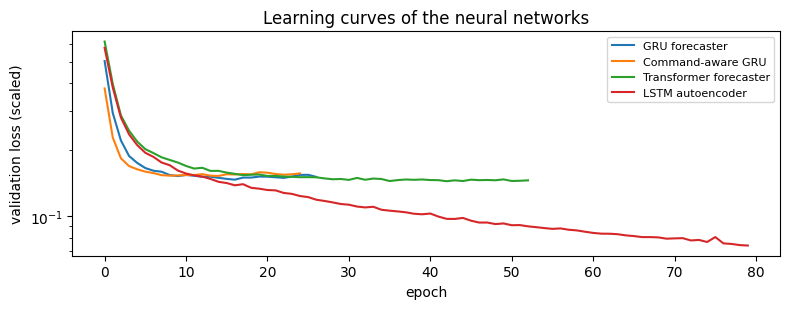

➜ Result: training time per method


,seconds
GRU forecaster,6.6
Command-aware GRU,5.3
Transformer forecaster,11.6
LSTM autoencoder,10.1
Isolation Forest,0.2


In [12]:
# Training summary
fig, ax = plt.subplots(figsize=(8, 3.2))
for name, h in HISTORY.items():
    ax.plot(np.array(h)[:, 1], label=name)
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("validation loss (scaled)")
ax.set_title("Learning curves of the neural networks"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("➜ Result: training time per method")
display(pd.Series(TRAIN_TIME, name="seconds").round(1).to_frame())

## Step 5 — RQ1: How well can the robot's motion be predicted?

**What we do:** ask each forecaster to predict the next 10 steps for every moment in the **test** recordings, and compare with what really happened.

**What we get:**
- **nRMSE:** average error over all state values, in units of each value's normal spread (lower is better).
- **Hand position error in millimetres**, 1 step and 10 steps ahead — the easiest number to understand.

(The autoencoder and Isolation Forest do not predict the future, so they are not in this table.)

,nRMSE,hand error 1 step [mm],hand error 10 steps [mm]
method,,,
Rule: stays still,0.551,7.103,68.384
Rule: keeps its speed,1.166,1.707,61.681
GRU forecaster,0.402,1.158,18.222
Transformer forecaster,0.404,1.012,18.014
Command-aware GRU,0.398,1.007,16.221


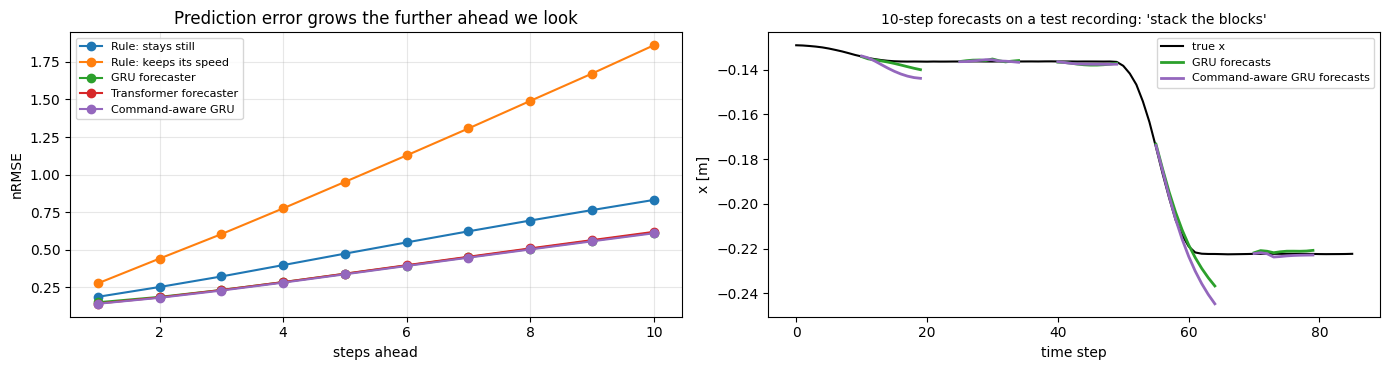

➜ Result (RQ1): best forecaster = Command-aware GRU: hand error 16.2 mm 10 steps ahead, vs 61.7 mm (keeps its speed) and 68.4 mm (stays still).


In [13]:
rows, per_horizon = [], {}
for name, predict in FORECASTERS.items():
    P = predict(Xte, Cte)
    per_horizon[name] = np.sqrt(((P - Yte) ** 2).mean(axis=(0, 2)))
    hand_mm = np.linalg.norm((P[:, :, XYZ] - Yte[:, :, XYZ]) * SD[XYZ], axis=-1) * 1000
    rows.append({"method": name, "nRMSE": float(np.sqrt(((P - Yte) ** 2).mean())),
                 "hand error 1 step [mm]": float(hand_mm[:, 0].mean()),
                 f"hand error {H} steps [mm]": float(hand_mm[:, -1].mean())})
rq1 = pd.DataFrame(rows).set_index("method")
rq1.to_csv(os.path.join(RESULTS_DIR, "rq1_forecasting.csv"))
display(rq1)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
for name, err in per_horizon.items():
    axes[0].plot(range(1, H + 1), err, marker="o", label=name)
axes[0].set_xlabel("steps ahead"); axes[0].set_ylabel("nRMSE"); axes[0].grid(alpha=0.3)
axes[0].set_title("Prediction error grows the further ahead we look"); axes[0].legend(fontsize=8)

i = TEST[0]
axes[1].plot(states[i][:, XYZ[0]], color="k", lw=1.5, label="true x")
Wz = sliding_window_view(Z[i], K, axis=0).transpose(0, 2, 1)
Wc = sliding_window_view(C[i], K, axis=0).transpose(0, 2, 1)
for t in range(K, len(Z[i]) - H, 15):
    for name, color in [("GRU forecaster", "C2"), ("Command-aware GRU", "C4")]:
        P = FORECASTERS[name](Wz[t - K:t - K + 1], Wc[t - K:t - K + 1])[0]
        axes[1].plot(range(t, t + H), (Z[i][t - 1, XYZ[0]] + P[:, XYZ[0]]) * SD[XYZ[0]] + MU[XYZ[0]], color=color, lw=2)
axes[1].plot([], [], color="C2", lw=2, label="GRU forecasts"); axes[1].plot([], [], color="C4", lw=2, label="Command-aware GRU forecasts")
axes[1].set_xlabel("time step"); axes[1].set_ylabel("x [m]"); axes[1].legend(fontsize=8)
axes[1].set_title(f"10-step forecasts on a test recording: '{instructions[i]}'", fontsize=10)
plt.tight_layout(); plt.show()

best_fc = rq1["nRMSE"].idxmin()
print(f"➜ Result (RQ1): best forecaster = {best_fc}: hand error {rq1.loc[best_fc, f'hand error {H} steps [mm]']:.1f} mm "
      f"10 steps ahead, vs {rq1.loc['Rule: keeps its speed', f'hand error {H} steps [mm]']:.1f} mm (keeps its speed) "
      f"and {rq1.loc['Rule: stays still', f'hand error {H} steps [mm]']:.1f} mm (stays still).")

## Step 6 — Create test failures with known location

**What we do:** the recordings contain no labelled failures, so — as is standard in anomaly-detection research — we add four kinds of failure to the **test** recordings. Because we add them ourselves, we know exactly where each one is.

| Failure | Simulates | How (size 1×) |
|---|---|---|
| **jerk** | collision, bump | sudden jump of 5 × a normal step on 3 values, for 5 steps |
| **freeze** | robot stalls, sensor stops updating | state stays constant for 15 steps while the robot is moving |
| **drift** | object slipping, calibration drift | offset growing to 10 × a normal step over 20 steps on 3 values |
| **noise** | faulty sensor, vibration | random noise of 3 × a normal step on all values for 10 steps |

Because this dataset's commands are rebuilt from the positions (Step 2), a damaged recording also gets damaged commands, exactly as a real failure would show up in the recorded data.

**What we get:** 66 damaged copies of the test recordings for each failure type (264 in total).

In [14]:
FAILURES = ["jerk", "freeze", "drift", "noise"]
FAIL_LEN = {"jerk": 5, "freeze": 15, "drift": 20, "noise": 10}

def inject(z, kind, rng, size=1.0):
    """Returns (damaged copy of z, label per time step, start step)."""
    z = z.copy()
    T, L = len(z), FAIL_LEN[kind]
    lo, hi = K + 5, T - L - 5
    if kind == "freeze":
        speed = np.linalg.norm(np.diff(z[:, CONT_DIMS], axis=0), axis=1)
        cand = [t for t in range(lo, hi) if speed[t - 1] > np.median(speed)]
        t0 = int(rng.choice(cand)) if cand else int(rng.integers(lo, hi))
    else:
        t0 = int(rng.integers(lo, hi))
    dims = rng.choice(CONT_DIMS, size=3, replace=False)
    sign = rng.choice([-1.0, 1.0], size=3)
    if kind == "jerk":
        z[t0:t0 + L, dims] += size * 5 * STEP_SD[dims] * sign
    elif kind == "freeze":
        z[t0:t0 + L] = z[t0 - 1]
    elif kind == "drift":
        z[t0:t0 + L, dims] += np.linspace(0, 1, L)[:, None] * size * 10 * STEP_SD[dims] * sign
    elif kind == "noise":
        z[t0:t0 + L, CONT_DIMS] += rng.normal(0, 1, (L, len(CONT_DIMS))) * size * 3 * STEP_SD[CONT_DIMS]
    label = np.zeros(T, bool)
    label[t0:t0 + L] = True
    return z.astype(np.float32), label, t0

def make_failures(size=1.0, seed=SEED):
    rng = np.random.default_rng(seed)
    return {kind: [(i, *inject(Z[i], kind, rng, size)) for i in TEST] for kind in FAILURES}

failure_set = make_failures()
print(f"➜ Result: {sum(len(v) for v in failure_set.values())} damaged test recordings "
      f"({', '.join(f'{len(v)} {k}' for k, v in failure_set.items())})")

➜ Result: 264 damaged test recordings (66 jerk, 66 freeze, 66 drift, 66 noise)


## Step 7 — Turn every method into an "unusualness score"

**What we do:** give every method a score for each time step: the higher, the more unusual.

| Method type | Score at time *t* |
|---|---|
| Forecasters (rules, GRU, Transformer, command-aware GRU) | how far the real state at *t* is from what the method predicted 1…10 steps earlier, compared with its normal error size |
| LSTM autoencoder | how badly it rebuilds the last 10 steps up to *t* |
| Isolation Forest | how isolated the last 10 steps up to *t* are |

Every score only uses information up to time *t*, so it could run live on a robot.

**Alarm threshold:** set on the clean **validation** recordings so that only about **5 % of normal recordings** raise an alarm. Every method gets the same false-alarm budget, which makes the comparison fair.

**What we get:** a score curve for every recording and an alarm threshold for every method.

In [15]:
smooth = lambda x: pd.Series(x).rolling(3, min_periods=1).mean().to_numpy()
RES_SD = {name: np.maximum((f(Xva, Cva) - Yva).std(0), 1e-3) for name, f in FORECASTERS.items()}

def forecast_score(z, c, name):
    predict, rsd = FORECASTERS[name], RES_SD[name]
    T = len(z)
    Wz = sliding_window_view(z, K, axis=0).transpose(0, 2, 1)[:T - K]            # window n ends at step K+n-1
    Wc = sliding_window_view(c, K, axis=0).transpose(0, 2, 1)[:T - K]            # commands up to the same step
    P = predict(np.ascontiguousarray(Wz), np.ascontiguousarray(Wc))
    acc, cnt = np.zeros(T), np.zeros(T)
    n = np.arange(len(P))
    for h in range(1, H + 1):
        tau = K + n - 1 + h
        ok = tau < T
        r = (z[tau[ok]] - (z[K + n[ok] - 1] + P[n[ok], h - 1])) / rsd[h - 1]
        acc[tau[ok]] += (r[:, CONT_DIMS] ** 2).mean(1)
        cnt[tau[ok]] += 1
    return smooth(np.where(cnt > 0, acc / np.maximum(cnt, 1), np.nan))

def autoencoder_score(z, c):
    W = sliding_window_view(z, K, axis=0).transpose(0, 2, 1)                   # window ends at step K-1 .. T-1
    x = ae_input(W)
    err = ((ae_reconstruct(x) - x) / AE_RES_SD) ** 2
    s = np.full(len(z), np.nan)
    s[K - 1:] = err[:, :, CONT_DIMS].mean(axis=(1, 2))
    return smooth(s)

def iforest_score(z, c):
    W = sliding_window_view(z, K, axis=0).transpose(0, 2, 1)
    s = np.full(len(z), np.nan)
    s[K - 1:] = -iforest.score_samples(iforest_features(W))
    return smooth(s)

DETECTORS = {
    "Rule: stays still":      lambda z, c: forecast_score(z, c, "Rule: stays still"),
    "Rule: keeps its speed":  lambda z, c: forecast_score(z, c, "Rule: keeps its speed"),
    "Isolation Forest":       iforest_score,
    "LSTM autoencoder":       autoencoder_score,
    "GRU forecaster":         lambda z, c: forecast_score(z, c, "GRU forecaster"),
    "Transformer forecaster": lambda z, c: forecast_score(z, c, "Transformer forecaster"),
    "Command-aware GRU":      lambda z, c: forecast_score(z, c, "Command-aware GRU"),
}
FAMILY = {"Rule: stays still": "rule", "Rule: keeps its speed": "rule", "Isolation Forest": "classic",
          "LSTM autoencoder": "rebuild", "GRU forecaster": "predict", "Transformer forecaster": "predict",
          "Command-aware GRU": "new idea"}

t0 = time.time()
clean_val = {name: [det(Z[i], C[i]) for i in VAL] for name, det in DETECTORS.items()}
clean_test = {name: [det(Z[i], C[i]) for i in TEST] for name, det in DETECTORS.items()}
THRESH = {name: float(np.quantile([np.nanmax(s) for s in scores], 0.95)) for name, scores in clean_val.items()}
print(f"➜ Result: scored all clean recordings for {len(DETECTORS)} methods in {time.time() - t0:.0f}s; "
      f"alarm thresholds set (5 % false-alarm budget)")

➜ Result: scored all clean recordings for 7 methods in 1s; alarm thresholds set (5 % false-alarm budget)


## Step 8 — RQ2: Which method detects failures best?

**What we do:** run all seven methods on the damaged and the clean test recordings and measure:

- **ROC-AUC** — how well the score separates failure moments from normal moments, without choosing a threshold. 1.0 = perfect, 0.5 = guessing.
- **Detection rate** — share of failures that trigger an alarm (during the failure, or up to 3 steps after).
- **Delay** — how many steps after the failure starts the alarm comes.
- **False alarms** — share of *clean* test recordings that raise an alarm anywhere (the budget was ~5 %).

**What we get:** a full comparison table, a ranking, and example pictures.

In [16]:
def roc_auc(scores, labels):
    order = np.argsort(scores, kind="mergesort")
    ranks = np.empty(len(scores)); ranks[order] = np.arange(1, len(scores) + 1)
    n_pos, n_neg = labels.sum(), (~labels).sum()
    return float((ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))

def evaluate(failure_set, names=None):
    names = names or list(DETECTORS)
    rows, damaged_scores = [], {}
    for name in names:
        clean = clean_test[name]
        false_alarm = float(np.mean([np.nanmax(s) > THRESH[name] for s in clean]))
        for kind, eps in failure_set.items():
            sc = [s[~np.isnan(s)] for s in clean]
            lb = [np.zeros(len(x), bool) for x in sc]
            hits, delays = [], []
            for i, zd, lab, t0 in eps:
                s = DETECTORS[name](zd, commands_from_scaled(zd))   # commands follow the damaged motion
                damaged_scores[(name, kind, i)] = s
                ok = ~np.isnan(s)
                sc.append(s[ok]); lb.append(lab[ok])
                alarm = np.where(s[t0:t0 + FAIL_LEN[kind] + 3] > THRESH[name])[0]
                hits.append(len(alarm) > 0)
                if len(alarm):
                    delays.append(alarm[0])
            rows.append({"method": name, "failure": kind,
                         "ROC-AUC": roc_auc(np.concatenate(sc), np.concatenate(lb)),
                         "detection rate": float(np.mean(hits)),
                         "delay [steps]": float(np.mean(delays)) if delays else np.nan,
                         "false alarms": false_alarm})
    return pd.DataFrame(rows), damaged_scores

t0 = time.time()
rq2, damaged_scores = evaluate(failure_set)
rq2.to_csv(os.path.join(RESULTS_DIR, "rq2_detection.csv"), index=False)
print(f"(evaluated in {time.time() - t0:.0f}s)")

auc = rq2.pivot(index="method", columns="failure", values="ROC-AUC")[FAILURES]
auc["average"] = auc.mean(1)
auc = auc.sort_values("average", ascending=False)
rate = rq2.pivot(index="method", columns="failure", values="detection rate")[FAILURES].loc[auc.index]
rate["false alarms"] = rq2.groupby("method")["false alarms"].first().loc[auc.index]
delay = rq2.pivot(index="method", columns="failure", values="delay [steps]")[FAILURES].loc[auc.index]

print("ROC-AUC (1.0 = perfect, 0.5 = guessing):"); display(auc.round(3))
print("Detection rate with a 5 % false-alarm budget:"); display(rate.round(2))
print("Average delay until the alarm [steps]:"); display(delay.round(1))

BEST = auc.index[0]
print(f"➜ Result (RQ2): best method overall = {BEST} (average ROC-AUC {auc.loc[BEST, 'average']:.3f})")
for kind in FAILURES:
    print(f"   {kind:>6}: best = {auc[kind].idxmax():<24} ROC-AUC {auc[kind].max():.3f}")

(evaluated in 2s)
ROC-AUC (1.0 = perfect, 0.5 = guessing):


failure,jerk,freeze,drift,noise,average
method,,,,,
Command-aware GRU,0.966,0.796,0.804,0.985,0.888
Transformer forecaster,0.975,0.744,0.787,0.986,0.873
GRU forecaster,0.967,0.760,0.779,0.985,0.873
LSTM autoencoder,0.930,0.317,0.794,0.958,0.750
Rule: keeps its speed,0.977,0.281,0.456,0.987,0.675
Rule: stays still,0.698,0.111,0.511,0.906,0.557
Isolation Forest,0.600,0.159,0.512,0.828,0.525


Detection rate with a 5 % false-alarm budget:


failure,jerk,freeze,drift,noise,false alarms
method,,,,,
Command-aware GRU,0.67,0.94,1.00,1.00,0.06
Transformer forecaster,0.94,0.94,1.00,1.00,0.08
GRU forecaster,0.83,0.94,1.00,1.00,0.09
LSTM autoencoder,0.12,0.82,0.92,1.00,0.09
Rule: keeps its speed,0.98,0.92,1.00,1.00,0.06
Rule: stays still,0.02,0.35,0.03,0.03,0.14
Isolation Forest,0.02,0.00,0.00,0.83,0.14


Average delay until the alarm [steps]:


failure,jerk,freeze,drift,noise
method,,,,
Command-aware GRU,1.5,13.3,20.0,0.5
Transformer forecaster,1.1,13.1,20.0,0.2
GRU forecaster,1.3,12.9,19.7,0.3
LSTM autoencoder,5.0,15.5,21.7,3.0
Rule: keeps its speed,0.4,13.0,19.7,0.1
Rule: stays still,0.0,15.5,22.0,9.0
Isolation Forest,5.0,NaN,NaN,8.8


➜ Result (RQ2): best method overall = Command-aware GRU (average ROC-AUC 0.888)
     jerk: best = Rule: keeps its speed    ROC-AUC 0.977
   freeze: best = Command-aware GRU        ROC-AUC 0.796
    drift: best = Command-aware GRU        ROC-AUC 0.804
    noise: best = Rule: keeps its speed    ROC-AUC 0.987


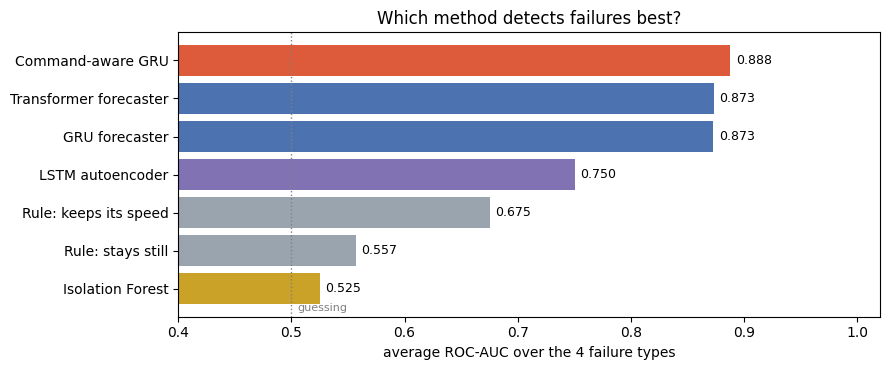

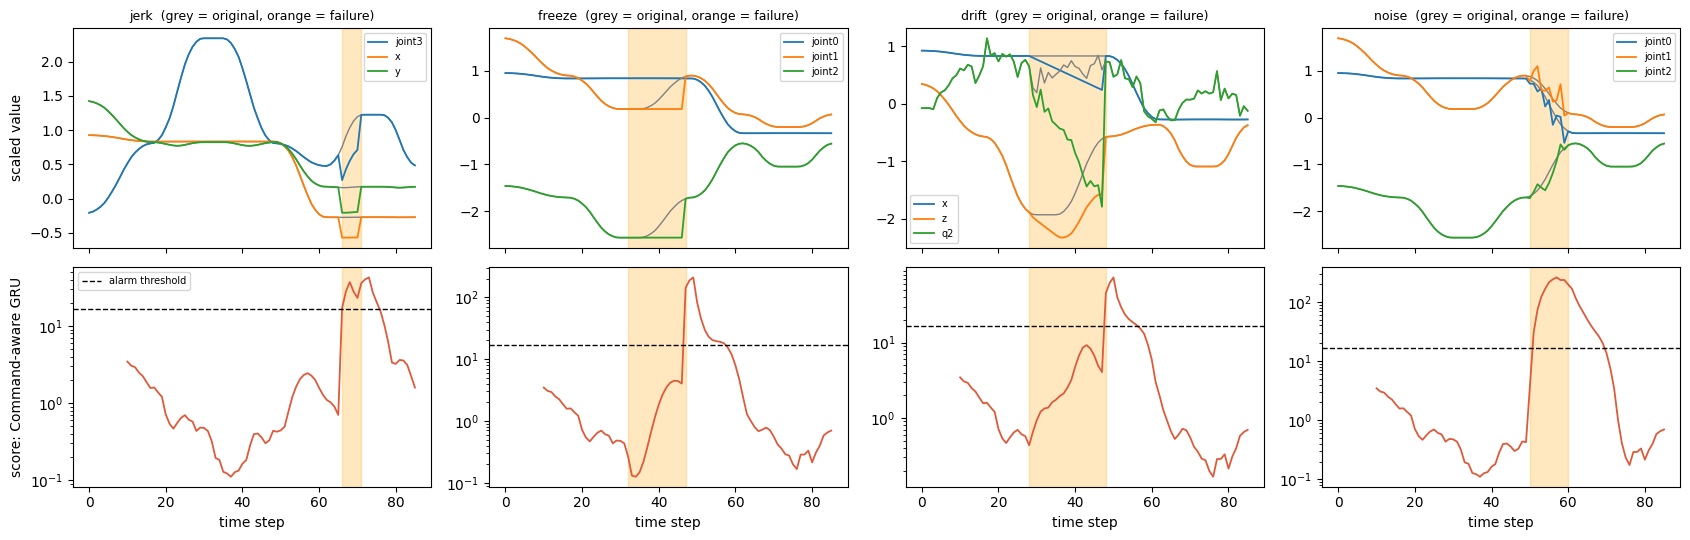

In [17]:
# Ranking chart
colors = {"rule": "#9aa4ae", "classic": "#c9a227", "rebuild": "#8172b3", "predict": "#4c72b0", "new idea": "#dd5a3a"}
fig, ax = plt.subplots(figsize=(9, 3.8))
order_ = auc["average"].sort_values()
ax.barh(order_.index, order_.values, color=[colors[FAMILY[n]] for n in order_.index])
for y, v in enumerate(order_.values):
    ax.text(v + 0.005, y, f"{v:.3f}", va="center", fontsize=9)
ax.axvline(0.5, color="grey", ls=":", lw=1); ax.text(0.505, -0.6, "guessing", fontsize=8, color="grey")
ax.set_xlim(0.4, 1.02); ax.set_xlabel("average ROC-AUC over the 4 failure types")
ax.set_title("Which method detects failures best?")
plt.tight_layout(); plt.show()

# Example: one damaged recording per failure type, with the best method's score
fig, axes = plt.subplots(2, 4, figsize=(17, 5.5), sharex="col")
for col, kind in enumerate(FAILURES):
    i, zd, lab, t0 = failure_set[kind][0]
    changed = np.where(np.abs(zd - Z[i]).max(0) > 1e-9)[0][:3]
    for d in changed:
        axes[0, col].plot(Z[i][:, d], color="grey", lw=1)
        axes[0, col].plot(zd[:, d], lw=1.3, label=NAMES[d])
    axes[1, col].plot(damaged_scores[(BEST, kind, i)], color="#dd5a3a", lw=1.3)
    axes[1, col].axhline(THRESH[BEST], color="k", ls="--", lw=1, label="alarm threshold")
    for ax in axes[:, col]:
        ax.axvspan(t0, t0 + FAIL_LEN[kind], color="orange", alpha=0.25)
    axes[0, col].set_title(f"{kind}  (grey = original, orange = failure)", fontsize=9)
    axes[0, col].legend(fontsize=7); axes[1, col].set_yscale("log"); axes[1, col].set_xlabel("time step")
axes[0, 0].set_ylabel("scaled value"); axes[1, 0].set_ylabel(f"score: {BEST}"); axes[1, 0].legend(fontsize=7)
plt.tight_layout(); plt.show()

## Step 9 — RQ2 (continued): What is the smallest failure each method can catch?

**What we do:** repeat the jerk, drift and noise failures at sizes 0.25×, 0.5×, 1× and 2× and measure the detection rate (freeze has no size, so it is left out).

**What we get:** one curve per method; the further left a curve rises, the smaller the failures it can catch.

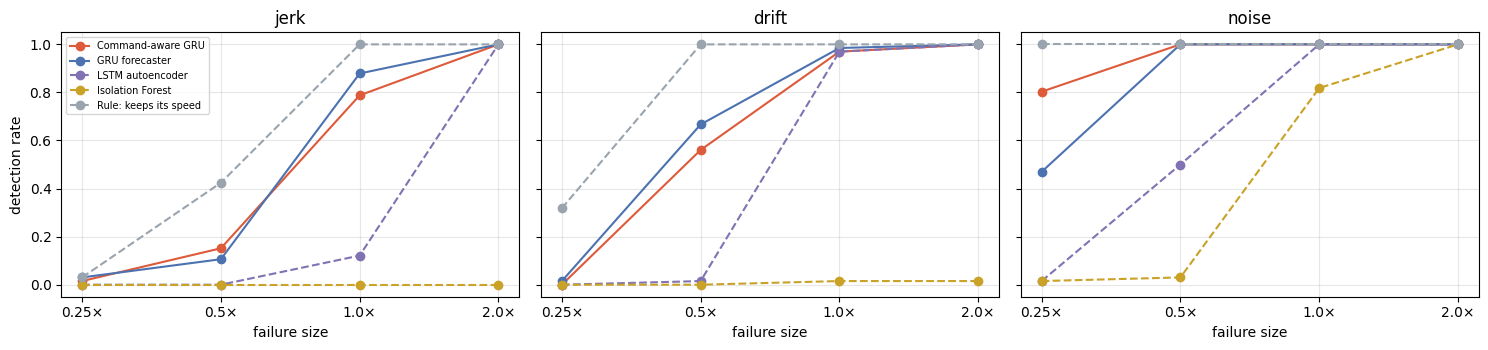

➜ Result: average detection rate for HALF-size failures (jerk, drift, noise):


,detection rate
method,
Rule: keeps its speed,0.81
GRU forecaster,0.59
Command-aware GRU,0.57
LSTM autoencoder,0.17
Isolation Forest,0.01


In [18]:
SIZES = [0.25, 0.5, 1.0, 2.0]
compare = list(dict.fromkeys([BEST, "Command-aware GRU", "GRU forecaster", "LSTM autoencoder",
                              "Isolation Forest", "Rule: keeps its speed"]))
sweep = []
for size in SIZES:
    fs = {k: v for k, v in make_failures(size, seed=SEED + 1).items() if k != "freeze"}
    res, _ = evaluate(fs, compare)
    res["size"] = size
    sweep.append(res)
sweep = pd.concat(sweep)
sweep.to_csv(os.path.join(RESULTS_DIR, "rq2_failure_size.csv"), index=False)

kinds = ["jerk", "drift", "noise"]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, kind in zip(axes, kinds):
    for name in compare:
        sel = sweep[(sweep.failure == kind) & (sweep.method == name)]
        ax.plot(sel["size"], sel["detection rate"], marker="o", color=colors[FAMILY[name]],
                ls="-" if FAMILY[name] in ("new idea", "predict") else "--", label=name)
    ax.set_xscale("log", base=2); ax.set_xticks(SIZES); ax.set_xticklabels([f"{s}×" for s in SIZES])
    ax.set_title(kind); ax.set_xlabel("failure size"); ax.grid(alpha=0.3)
axes[0].set_ylabel("detection rate"); axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

small = sweep[sweep["size"] == 0.5].groupby("method")["detection rate"].mean().sort_values(ascending=False)
print("➜ Result: average detection rate for HALF-size failures (jerk, drift, noise):")
display(small.round(2).to_frame())

## Step 10 — RQ3: Do the robot's commands reduce false alarms?

**What we do:** compare the **GRU forecaster** and the **Command-aware GRU** side by side. They are the same network; the only difference is that the second one also sees the commands. We look at:

1. prediction accuracy (from Step 5),
2. failure detection (from Step 8),
3. **false alarms on clean recordings**: how often each one alarms when nothing is wrong,
4. the recording where the plain GRU is most "confused".

**Important data finding (from the check in Step 2).** In this dataset the recorded "command" is **exactly** the change of the hand position since the previous step (`command[t] = position[t] − position[t−1]`) plus the current gripper state. It is the recorded movement written down a second time, not an independent instruction from the controller. So the commands give the model **no information that is not already in the past states**, and RQ3 **cannot be tested properly with this dataset**. The two models below receive the same information, one of them in two forms. Small differences between them can come from training randomness or from the repeated form of the same information; they are not evidence that real controller commands would help. Repeating the comparison with several random seeds shows how large the randomness is.

Two traps were found on the way, and both are worth a sentence in the thesis:
1. Feeding the model commands from *after* time *t* reveals the future movement and makes results look far too good.
2. Damaging the positions of a test recording but leaving its recorded commands untouched lets the commands "remember" the undamaged motion, which again looks like a large but fake improvement.

**What we get:** an honest answer to RQ3 and the evidence behind it.

,hand error 10 steps [mm],average ROC-AUC,freeze ROC-AUC,drift ROC-AUC,clean recordings with an alarm,alarm steps per clean recording
GRU forecaster,18.222,0.873,0.760,0.779,0.091,1.364
Command-aware GRU,16.221,0.888,0.796,0.804,0.061,1.136


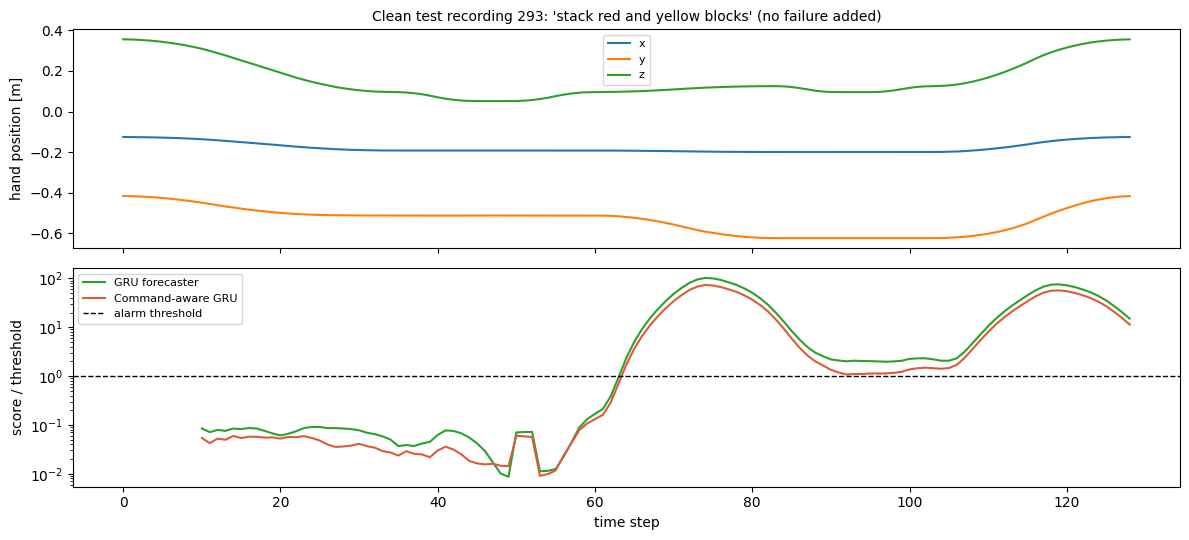

➜ Result (RQ3): with commands, the 10-step hand error goes from 18.2 to 16.2 mm, average ROC-AUC from 0.873 to 0.888, alarm steps per clean recording from 1.36 to 1.14.


In [19]:
pair = ["GRU forecaster", "Command-aware GRU"]
alarm_steps = {n: float(np.mean([np.nansum(s > THRESH[n]) for s in clean_test[n]])) for n in pair}
normal_level = {n: float(np.nanmedian(np.concatenate(clean_test[n]))) for n in pair}

rq3 = pd.DataFrame({
    f"hand error {H} steps [mm]": rq1.loc[pair, f"hand error {H} steps [mm]"],
    "average ROC-AUC": auc.loc[pair, "average"],
    "freeze ROC-AUC": auc.loc[pair, "freeze"],
    "drift ROC-AUC": auc.loc[pair, "drift"],
    "clean recordings with an alarm": rate.loc[pair, "false alarms"],
    "alarm steps per clean recording": pd.Series(alarm_steps),
})
rq3.to_csv(os.path.join(RESULTS_DIR, "rq3_commands.csv"))
display(rq3.round(3))

# the clean test recording where the plain GRU is most surprised
worst = TEST[int(np.argmax([np.nanmax(s) for s in clean_test["GRU forecaster"]]))]
k = list(TEST).index(worst)
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
for d in XYZ:
    axes[0].plot(states[worst][:, d], label=NAMES[d])
axes[0].set_ylabel("hand position [m]"); axes[0].legend(fontsize=8)
axes[0].set_title(f"Clean test recording {worst}: '{instructions[worst]}' (no failure added)", fontsize=10)
for n, color in zip(pair, ["C2", "#dd5a3a"]):
    axes[1].plot(clean_test[n][k] / THRESH[n], color=color, label=n)
axes[1].axhline(1.0, color="k", ls="--", lw=1, label="alarm threshold")
axes[1].set_yscale("log"); axes[1].set_ylabel("score / threshold"); axes[1].set_xlabel("time step")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

g, c = rq3.loc["GRU forecaster"], rq3.loc["Command-aware GRU"]
print(f"➜ Result (RQ3): with commands, the {H}-step hand error goes from {g.iloc[0]:.1f} to {c.iloc[0]:.1f} mm, "
      f"average ROC-AUC from {g['average ROC-AUC']:.3f} to {c['average ROC-AUC']:.3f}, "
      f"alarm steps per clean recording from {g['alarm steps per clean recording']:.2f} to {c['alarm steps per clean recording']:.2f}.")

## Step 11 — Are there real unusual moments in the recordings?

**What we do:** run the best method over **all** recordings, without adding any failure, and list the most unusual ones.

**What we get:** a short list of recordings worth watching on video. If they show real problems (hesitation, a slip, a correction by the operator, a recording glitch), they become **real, hand-checked examples** for the thesis.

Note: training recordings were seen during learning, so their scores are a bit lower than they would otherwise be; the ranking is still useful.

In [20]:
split_of = {int(i): "train" for i in TRAIN} | {int(i): "val" for i in VAL} | {int(i): "test" for i in TEST}
real = []
for i in range(len(Z)):
    s = DETECTORS[BEST](Z[i], C[i])
    real.append({"recording": i, "split": split_of[i], "task": instructions[i],
                 "peak score / threshold": float(np.nanmax(s) / THRESH[BEST]),
                 "peak at step": int(np.nanargmax(s)), "length": len(s), "file": file_names[i]})
real = pd.DataFrame(real).sort_values("peak score / threshold", ascending=False).reset_index(drop=True)
real.to_csv(os.path.join(RESULTS_DIR, "real_recording_ranking.csv"), index=False)
display(real.head(10))

n_flagged = int((real["peak score / threshold"] > 1).sum())
print(f"➜ Result: {n_flagged} of {len(real)} recordings cross the alarm threshold of '{BEST}'. "
      f"Most unusual: recording {real.iloc[0]['recording']} ('{real.iloc[0]['task']}') at step {real.iloc[0]['peak at step']}.")

,recording,split,task,peak score / threshold,peak at step,length,file
0,293,test,stack red and yellow blocks,73.266,74,129,stack_red_and_yellow_blocks_20250707_102443_ED...
1,18,val,stack the cups,2.871,125,153,stack_the_cups_20250731_142458.npz
2,36,test,pick up the blue block and drop it in the box,2.376,59,90,pick_up_the_blue_block_and_drop_it_in_the_box_...
3,205,val,pick and place the yellow block in the box,1.612,63,110,pick_and_place_the_yellow_block_in_the_box_202...
4,89,test,stack the blocks,1.376,10,82,stack_the_blocks_20250813_132843.npz
5,234,val,stack the blocks,1.268,10,93,stack_the_blocks_20250730_121806_EDITED.npz
6,75,val,transfer the yellow and red blocks in to the box,1.027,64,216,transfer_the_yellow_and_red_blocks_in_to_the_b...
7,316,test,stack the cups,1.024,10,109,stack_the_cups_20250731_150335.npz
8,270,train,drop the blue block in the cardboard box,1.008,77,108,drop_the_blue_block_in_the_cardboard_box_20250...
9,44,test,drop yellow block into the box,0.932,57,115,drop_yellow_block_into_the_box_20250721_123725...


➜ Result: 9 of 443 recordings cross the alarm threshold of 'Command-aware GRU'. Most unusual: recording 293 ('stack red and yellow blocks') at step 74.


## Step 12 — Final answers to the research questions

In [21]:
fc_learned = rq1.drop(["Rule: stays still", "Rule: keeps its speed"])
best_fc = fc_learned["nRMSE"].idxmin()
col10 = f"hand error {H} steps [mm]"
slow = auc[["freeze", "drift"]].mean(1)
fast = auc[["jerk", "noise"]].mean(1)
best_rule = max(["Rule: stays still", "Rule: keeps its speed"], key=lambda n: auc.loc[n, "average"])

g, c = rq3.loc["GRU forecaster"], rq3.loc["Command-aware GRU"]
fewer_alarms = c["alarm steps per clean recording"] < g["alarm steps per clean recording"]
better_auc = c["average ROC-AUC"] > g["average ROC-AUC"] + 0.005
if CMD_EQUALS_PAST_MOVE > 0.99:
    verdict = (f"CANNOT BE TESTED WITH THIS DATASET: the recorded commands equal the past movement and gripper state\n"
               f"   ({CMD_EQUALS_PAST_MOVE:.0%} of steps), so they add no new information. The small differences below may come from\n"
               f"   training randomness or from showing the same information twice; run several seeds to check.")
elif fewer_alarms and better_auc:
    verdict = "YES: commands reduce false alarms and improve detection."
elif fewer_alarms or better_auc:
    verdict = "PARTLY: commands help on one side (see numbers), not on both."
else:
    verdict = "NO: in this setup the commands did not help; this is itself a finding to discuss."

print(f"""
RQ1 — Can the motion be predicted?
   Yes. The best learned forecaster ({best_fc}) predicts the hand position {H} steps ahead with a
   {fc_learned.loc[best_fc, col10]:.1f} mm error, vs {rq1.loc['Rule: keeps its speed', col10]:.1f} mm for 'keeps its speed' and
   {rq1.loc['Rule: stays still', col10]:.1f} mm for 'stays still'.

RQ2 — Can failures be detected, and which method is best?
   Best overall: {BEST} (average ROC-AUC {auc.loc[BEST, 'average']:.3f}).
   Fast failures (jerk, noise): even the best rule reaches {fast[best_rule]:.3f}; best method {fast.max():.3f} ({fast.idxmax()}).
   Slow failures (freeze, drift): best rule {slow[best_rule]:.3f} vs best method {slow.max():.3f} ({slow.idxmax()}).
   Isolation Forest {auc.loc['Isolation Forest', 'average']:.3f}, LSTM autoencoder {auc.loc['LSTM autoencoder', 'average']:.3f},
   GRU {auc.loc['GRU forecaster', 'average']:.3f}, Transformer {auc.loc['Transformer forecaster', 'average']:.3f},
   Command-aware GRU {auc.loc['Command-aware GRU', 'average']:.3f}.

RQ3 — Do commands reduce false alarms?
   {verdict}
   Alarm steps per clean recording: {g['alarm steps per clean recording']:.2f} (GRU) -> {c['alarm steps per clean recording']:.2f} (Command-aware GRU)
   Average ROC-AUC: {g['average ROC-AUC']:.3f} -> {c['average ROC-AUC']:.3f};  {H}-step hand error: {g.iloc[0]:.1f} -> {c.iloc[0]:.1f} mm
""")

summary = auc[["average", "freeze", "drift", "jerk", "noise"]].copy()
summary.insert(0, "family", [FAMILY[n] for n in summary.index])
summary["false alarms"] = rate["false alarms"]
summary["train time [s]"] = pd.Series(TRAIN_TIME).reindex(summary.index).fillna(0.0)
summary.to_csv(os.path.join(RESULTS_DIR, "summary_all_methods.csv"))
print("Summary of all methods (ROC-AUC per failure type):")
display(summary.round(3))


RQ1 — Can the motion be predicted?
   Yes. The best learned forecaster (Command-aware GRU) predicts the hand position 10 steps ahead with a
   16.2 mm error, vs 61.7 mm for 'keeps its speed' and
   68.4 mm for 'stays still'.

RQ2 — Can failures be detected, and which method is best?
   Best overall: Command-aware GRU (average ROC-AUC 0.888).
   Fast failures (jerk, noise): even the best rule reaches 0.982; best method 0.982 (Rule: keeps its speed).
   Slow failures (freeze, drift): best rule 0.369 vs best method 0.800 (Command-aware GRU).
   Isolation Forest 0.525, LSTM autoencoder 0.750,
   GRU 0.873, Transformer 0.873,
   Command-aware GRU 0.888.

RQ3 — Do commands reduce false alarms?
   CANNOT BE TESTED WITH THIS DATASET: the recorded commands equal the past movement and gripper state
   (100% of steps), so they add no new information. The small differences below may come from
   training randomness or from showing the same information twice; run several seeds to check.
   Alarm s

failure,family,average,freeze,drift,jerk,noise,false alarms,train time [s]
method,,,,,,,,
Command-aware GRU,new idea,0.888,0.796,0.804,0.966,0.985,0.061,5.295
Transformer forecaster,predict,0.873,0.744,0.787,0.975,0.986,0.076,11.647
GRU forecaster,predict,0.873,0.760,0.779,0.967,0.985,0.091,6.636
LSTM autoencoder,rebuild,0.750,0.317,0.794,0.930,0.958,0.091,10.115
Rule: keeps its speed,rule,0.675,0.281,0.456,0.977,0.987,0.061,0.000
Rule: stays still,rule,0.557,0.111,0.511,0.698,0.906,0.136,0.000
Isolation Forest,classic,0.525,0.159,0.512,0.600,0.828,0.136,0.238


## What to do next in the thesis

- **Check Step 11 by eye:** watch the camera frames of the top recordings and label what really happened. This gives real, not injected, failures.
- **Repeat with 3–5 different random seeds** and report the average and spread, so the comparison is statistically fair.
- **Replace RQ3.** The commands in this dataset are not independent, so RQ3 needs a new idea that the data can support, for example an *uncertainty-aware forecaster* that also predicts how sure it is (fewer false alarms at hard-to-predict moments), or a *task-phase-aware* model that knows whether the gripper is holding an object. Alternatively, ask the dataset author whether the real controller commands were logged.
- **Write it up:** Step 5 answers RQ1, Steps 8–9 answer RQ2, Step 10 answers RQ3. Every table is also saved as a CSV file in `results/`.